In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def extract_regions(df, suffix):
    return sorted([col.replace(suffix, "") 
                   for col in df.columns if col.endswith(suffix)])

In [8]:
def convert_long(df, mode,name):
    suffix = f"_{mode}_{name}"
    value_cols = [c for c in df.columns if c.endswith(suffix)]
    
    df_long = df.melt(
        id_vars="year",
        value_vars=value_cols,
        var_name="region_full",
        value_name=mode
    )
    df_long["17region"] = df_long["region_full"].str.replace(suffix, "", regex=False)
    df_long = df_long.drop(columns=["region_full"])
    return df_long

In [13]:
def main(name):
    # df_basin  = pd.read_csv(f"../../CSV/moran/basin_{name}_moran_3f.csv")
    # df_region = pd.read_csv(f"../../CSV/moran/region_{name}_moran_3f.csv")
    df_world  = pd.read_csv("../../CSV/moran/world_moran_3f.csv")
    df_basin  = pd.read_csv(f"../../CSV/moran/basin_{name}_moran_interannual_diff.csv")
    df_region = pd.read_csv(f"../../CSV/moran/region_{name}_moran_interannual_diff.csv")

    regions = extract_regions(df_basin, f"_basin_{name}")

    df_basin_long  = convert_long(df_basin,  mode="basin",  name=name)
    df_region_long = convert_long(df_region, mode="region", name=name)

    df_merged = pd.merge(
        df_basin_long, df_region_long,
        on=["year", "17region"], how="inner"
    )

    # ===== 加上 World =====
    regions_all = regions + ["World"]

    n = len(regions_all)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(8, 10),
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    for i, reg in enumerate(regions_all):
        ax = axes[i]

        # ---------- 17 regions ----------
        if reg != "World":
            d = df_merged[df_merged["17region"] == reg]
            ax.plot(d["year"], d["basin"],  color="blue", label="Basin")
            ax.plot(d["year"], d["region"], color="red",  label="Region")
            ax.set_title(reg)

        # ---------- World ----------
        else:
            ax.plot(df_world["year"], df_world[f"basin_{name}"],
                    color="blue", label="Basin")
            ax.plot(df_world["year"], df_world[f"region_{name}"],
                    color="red", label="Region")
            ax.set_title("World")

        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

        # ---------- 行列位置 ----------
        row = i // ncols
        col = i % ncols

        # 左列显示 y 轴
        if col == 0:
            ax.set_ylabel("Global Moran's I", fontsize=13)
            ax.tick_params(axis="y", labelleft=True)
        else:
            ax.tick_params(axis="y", labelleft=False)

        # 底行显示 x 轴
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=13)
            ax.tick_params(axis="x", labelbottom=True)
        else:
            ax.tick_params(axis="x", labelbottom=False)

    # ---------- legend（只放一次） ----------
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.8, 0.1),
        ncol=1,
        fontsize=12
    )


    # ---------- 删除多余子图 ----------
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(
        f"../../plot/moran/splitregions_17regions_plus_world_{name}_moran_interannual_diff.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()


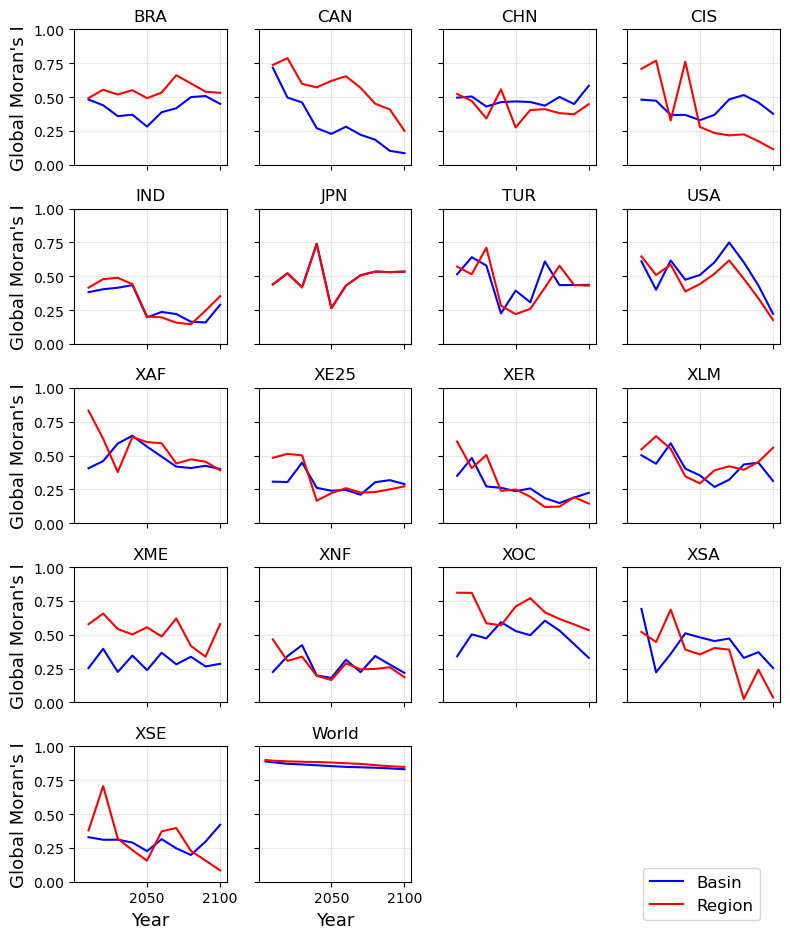

In [14]:
names=["agri","forest","grassland"]
names=["agri"]
for name in names:
    main(name)